# Module 05: Scikit-Learn for Machine Learning
## Notebook 04: Unsupervised Learning: Clustering and Dimensionality Reduction

Unsupervised learning algorithms find hidden structures, natural groupings, and compressed latent representations in unlabeled data.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Reduce dimensionality and visualize high-dimensional data using **`PCA`**.
2. Plot and interpret the **Scree Plot** and cumulative explained variance.
3. Group observations using the **`KMeans`** clustering algorithm.
4. Select the optimal number of clusters ($K$) using the **Elbow Method** and **Silhouette Score**.
5. Combine PCA and K-Means for end-to-end customer segmentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

print("Loaded Scikit-Learn Unsupervised Modules!")

Loaded Scikit-Learn Unsupervised Modules!


### 1. Principal Component Analysis (PCA)

PCA identifies orthogonal directions (principal components) along which the variance of data is maximized.
- **Dimensionality Reduction**: Projecting from $D$ features down to $K$ principal components ($K \ll D$).
- **Data Compression**: Preserves maximum variance while removing noise.
- **Visualization**: Projecting high-dimensional data into 2D or 3D scatter plots.

> **Always Standardize Before PCA:**
> Because PCA seeks directions of maximal variance, features with larger arbitrary numerical scales (e.g. Income in $100,000 vs Age in 40) will artificially dominate the principal components unless standardized!

In [2]:
# Generate 6-dimensional synthetic clustered data
X_raw, y_true = make_blobs(n_samples=300, n_features=6, centers=3, cluster_std=1.2, random_state=42)

# 1. Standardize features
X_scaled = StandardScaler().fit_transform(X_raw)

# 2. Fit PCA with all 6 components to inspect variance distribution
pca_full = PCA().fit(X_scaled)
exp_var_ratio = pca_full.explained_variance_ratio_

print("Explained variance ratio per component:\n", np.round(exp_var_ratio, 4))
print(f"Total variance captured by first 2 components: {np.sum(exp_var_ratio[:2]) * 100:.1f}%")

Explained variance ratio per component:
 [0.7373 0.2165 0.0226 0.0097 0.0087 0.0053]
Total variance captured by first 2 components: 95.4%


---
### 2. Scree Plot and 2D Projection

The **Scree Plot** displays the fraction of total variance explained by each consecutive component, helping you choose the minimal number of dimensions to retain.

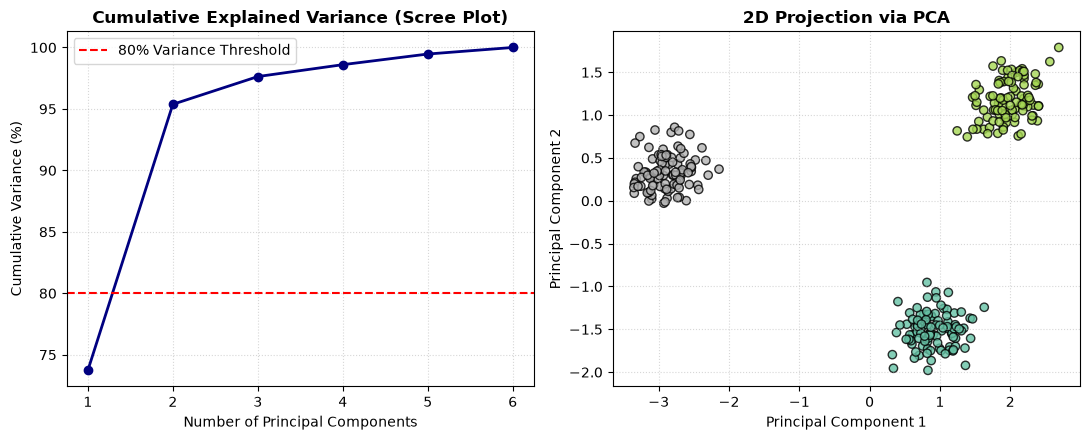

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1. Scree Plot
components = np.arange(1, len(exp_var_ratio) + 1)
ax1.plot(components, np.cumsum(exp_var_ratio) * 100, 'o-', color='navy', linewidth=2)
ax1.axhline(80, color='red', linestyle='--', label='80% Variance Threshold')
ax1.set_title("Cumulative Explained Variance (Scree Plot)", fontweight='bold')
ax1.set_xlabel("Number of Principal Components")
ax1.set_ylabel("Cumulative Variance (%)")
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend()

# 2. Project data down to 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

scatter = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_true, cmap='Set2', edgecolor='k', alpha=0.8)
ax2.set_title("2D Projection via PCA", fontweight='bold')
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 3. K-Means Clustering: Finding Optimal $K$

The K-Means algorithm partitions data into $K$ spherical clusters by iteratively minimizing the within-cluster sum-of-squares (**Inertia**).

How to choose $K$:
- **Elbow Method**: Look for the point of diminishing returns (the "elbow") on the Inertia curve.
- **Silhouette Analysis**: Measures how similar an object is to its own cluster compared to other clusters (ranges from $-1$ to $+1$; higher is better).

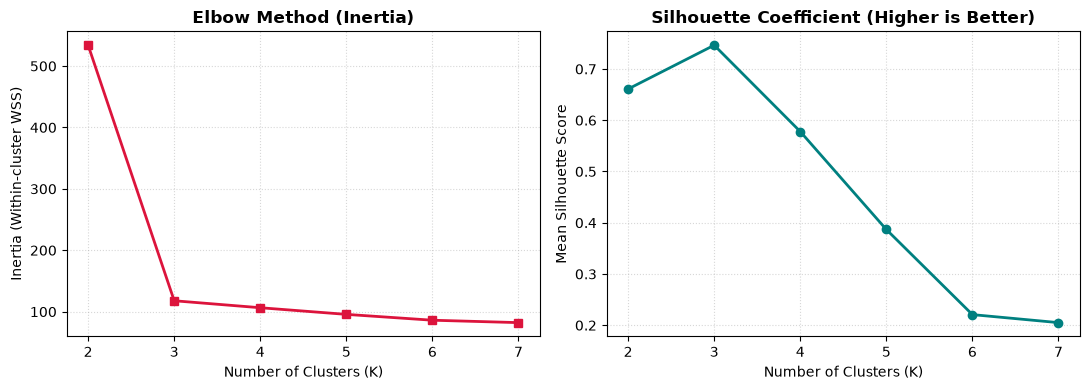

In [4]:
k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Elbow Curve
ax1.plot(k_range, inertias, 's-', color='crimson', linewidth=2)
ax1.set_title("Elbow Method (Inertia)", fontweight='bold')
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (Within-cluster WSS)")
ax1.grid(True, linestyle=':', alpha=0.5)

# Silhouette Score
ax2.plot(k_range, silhouettes, 'o-', color='teal', linewidth=2)
ax2.set_title("Silhouette Coefficient (Higher is Better)", fontweight='bold')
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Mean Silhouette Score")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- Standardizing features for PCA.
- Scree plots and variance explained ratios.
- K-Means clustering mechanics.
- The Elbow Method and Silhouette Analysis for finding the optimal $K$.

**Next Notebook:** `05_evaluation_metrics_and_hyperparameter_tuning.ipynb` — K-Fold Cross-Validation, GridSearchCV, RandomizedSearchCV, and model serialization with Joblib.